In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
m = 2.567
c = 0.123
X = np.arange(1,100,0.09)
y = m*X + c
split = int(len(X)*0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

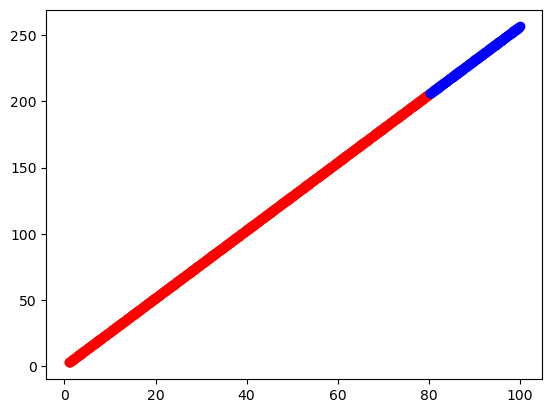

In [3]:
def plot_data(
    X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test,
    predictions = None):
    plt.scatter(X_train, y_train, c='r', label='Training Data')
    plt.scatter(X_test, y_test, c='b', label='Testing Data')
    if predictions is not None:
        plt.scatter(X_test, predictions, c='g', label='Predicted Data')

plot_data()

In [4]:
W = np.random.randn()
b = np.random.randn()
print(f'Initially W = {W} and bias = {b}')

Initially W = -0.5313963392098787 and bias = 0.781351286332608


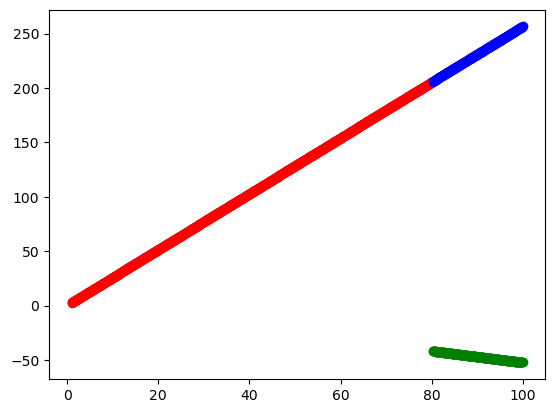

In [5]:
y_preds = X_test*W + b
plot_data(predictions=y_preds)

In [6]:
def loss_function(y_actual, y_preds):
    return (1/len(X_train)*np.sum(np.square(y_actual-y_preds)))

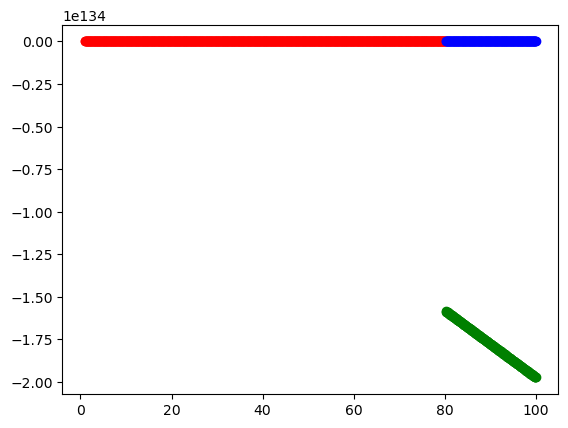

In [7]:
epochs = 50
lr = 0.1
train_loss_list = []
test_loss_list = []
for i in range(epochs):
    # Forward Pass
    train_preds = X_train*W + b
    train_loss = loss_function(y_train, train_preds)
    # Compute the gradient
    gradient_W = (-2/len(y_train))*np.sum((y_train - train_preds)*X_train)
    gradient_b = (-2/len(y_train))*np.sum((y_train-train_preds))
    # Gradient Descent
    W = W - lr*gradient_W
    b = b - lr*gradient_b
    # Evaluate the Loss on Test Set
    test_preds = X_test*W + b
    test_loss = loss_function(y_test, test_preds)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    
y_out = X_test*W + b
plot_data(predictions=y_out)

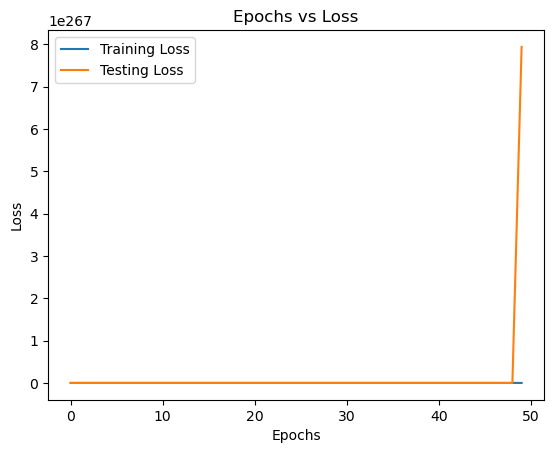

In [8]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [9]:
print(f'Finally W={W} and b={b}')

Finally W=-1.9744686318589063e+132 and b=-3.6948635516337743e+130


In [10]:
import torch
print(torch.__version__)

2.13.0+cu130


In [11]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device= {device}")

Using device= cuda
